### Importación de datos



In [1]:
import pandas as pd
import matplotlib

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [2]:
import locale     # Servicios de internacionalización

locale.setlocale(locale.LC_ALL, '') # Establece la configuración regional

# Formatear con el símbolo de moneda y agrupamiento de miles
# moneda_formateada = locale.currency(valor, grouping=True)

fact_T1 = sum(tienda["Precio"])
fact_T2 = sum(tienda2["Precio"])
fact_T3 = sum(tienda3["Precio"])
fact_T4 = sum(tienda4["Precio"])

factura_total_T1 = locale.currency(sum(tienda["Precio"]),grouping=True)              # Facturación total de tienda 1
factura_total_T2 = locale.currency(sum(tienda2["Precio"]),grouping=True)             # Facturación total de tienda 2
factura_total_T3 = locale.currency(sum(tienda3["Precio"]),grouping=True)             # Facturación total de tienda 3
factura_total_T4 = locale.currency(sum(tienda4["Precio"]),grouping=True)             # Facturación total de tienda 4

print(f"La facturación total de la tienda 1 es: {factura_total_T1}")
print(f"La facturación total de la tienda 2 es: {factura_total_T2}")
print(f"La facturación total de la tienda 3 es: {factura_total_T3}")
print(f"La facturación total de la tienda 4 es: {factura_total_T4}")


La facturación total de la tienda 1 es: $1,150,880,400.00
La facturación total de la tienda 2 es: $1,116,343,500.00
La facturación total de la tienda 3 es: $1,098,019,600.00
La facturación total de la tienda 4 es: $1,038,375,700.00


# 2. Ventas por categoría

In [44]:
# Extrayendo cantidad de elementos vendidos por categoría

'''
# Separando lista de categorías

# Usando bucle for normal
tienda["Categoría del Producto"]
categorias = []
for name in tienda["Categoría del Producto"]:
    if name not in categorias:
        categorias.append(name)
print(categorias)

# Usando list comprehension
categorias = list(set([name for name in tienda2["Categoría del Producto"]]))
print(categorias)


# Usando la opción list(set())
categorias = list(set(tienda2["Categoría del Producto"]))

# Creando una lista de listas con valores repetidos de cada categoría
lista_de_listas = []
for categoria in categorias:
    lista = [e for e in tienda2["Categoría del Producto"] if e == categoria]
    lista_de_listas.append(lista)
#print(lista_de_listas)

# Conteo de cuantos elementos se encuentran por categoria
conteo_valores = {categorias[i]: len(lista_de_listas[i]) for i in range(len(categorias))}
print(conteo_valores)
'''

# Usando una función

def conteo_valores(La_Tienda):
  lista_de_listas = []

  categorias = list(set(La_Tienda["Categoría del Producto"]))

  for categoria in categorias:
    lista = [e for e in La_Tienda["Categoría del Producto"] if e == categoria]
    lista_de_listas.append(lista)

  valores = {categorias[i]: len(lista_de_listas[i]) for i in range(len(categorias))}

  return valores

# Calculamos la cantidad de elementos por categoría y los ordenamos de mayor a menor en ventas
ventas_cat_tienda1 = dict(sorted(conteo_valores(tienda).items(),key=lambda item: item[1],reverse=True))
ventas_cat_tienda2 = dict(sorted(conteo_valores(tienda2).items(),key=lambda item: item[1],reverse=True))
ventas_cat_tienda3 = dict(sorted(conteo_valores(tienda3).items(),key=lambda item: item[1],reverse=True))
ventas_cat_tienda4 = dict(sorted(conteo_valores(tienda4).items(),key=lambda item: item[1],reverse=True))

#print(f"La cantidad de productos vendidos por categoría para la tienda 1 son: {ventas_cat_tienda1}")
#print(f"La cantidad de productos vendidos por categoría para la tienda 2 son: {ventas_cat_tienda2}")
#print(f"La cantidad de productos vendidos por categoría para la tienda 3 son: {ventas_cat_tienda3}")
#print(f"La cantidad de productos vendidos por categoría para la tienda 4 son: {ventas_cat_tienda4}")

print("La cantidad de productos vendidos por categoría para la tienda 1 es:")
format_print2(ventas_cat_tienda1)
print()
print("La cantidad de productos vendidos por categoría para la tienda 2 es:")
format_print2(ventas_cat_tienda2)
print()
print("La cantidad de productos vendidos por categoría para la tienda 3 es:")
format_print2(ventas_cat_tienda3)
print()
print("La cantidad de productos vendidos por categoría para la tienda 4 es:")
format_print2(ventas_cat_tienda4)

La cantidad de productos vendidos por categoría para la tienda 1 es:

Producto                                Ventas
------------------------------
  Muebles                       :   465
  Electrónicos                  :   448
  Juguetes                      :   324
  Electrodomésticos             :   312
  Deportes y diversión          :   284
  Instrumentos musicales        :   182
  Libros                        :   173
  Artículos para el hogar       :   171


La cantidad de productos vendidos por categoría para la tienda 2 es:

Producto                                Ventas
------------------------------
  Muebles                       :   442
  Electrónicos                  :   422
  Juguetes                      :   313
  Electrodomésticos             :   305
  Deportes y diversión          :   275
  Instrumentos musicales        :   224
  Libros                        :   197
  Artículos para el hogar       :   181


La cantidad de productos vendidos por categoría para la tien

In [4]:
# Extrayendo facturación de ventas por categoría

# Usando una función
def calcular_ventas_por_categoria(tienda):

  ventas_por_categoria = {}

  for i in range(len(tienda["Categoría del Producto"])):
    categoria = tienda["Categoría del Producto"][i]
    venta = tienda["Precio"][i]
    if categoria in ventas_por_categoria:
      ventas_por_categoria[categoria] += venta
    else:
      ventas_por_categoria[categoria] = venta

  return {k: float(v) for k, v in ventas_por_categoria.items()}     # Para evitar el np.float64
   #return ventas_por_categoria

# Calculamos la facturación por categoría y ordenamos de mayor a menor
fact_por_cat_T1 = dict(sorted(calcular_ventas_por_categoria(tienda).items(),key=lambda item: item[1],reverse=True))
fact_por_cat_T2 = dict(sorted(calcular_ventas_por_categoria(tienda2).items(),key=lambda item: item[1],reverse=True))
fact_por_cat_T3 = dict(sorted(calcular_ventas_por_categoria(tienda3).items(),key=lambda item: item[1],reverse=True))
fact_por_cat_T4 = dict(sorted(calcular_ventas_por_categoria(tienda4).items(),key=lambda item: item[1],reverse=True))

#print(f"La facturación por categoría para la tienda 1 es: {fact_por_cat_T1}")
#print(f"La facturación por categoría para la tienda 2 es: {fact_por_cat_T2}")
#print(f"La facturación por categoría para la tienda 3 es: {fact_por_cat_T3}")
#print(f"La facturación por categoría para la tienda 4 es: {fact_por_cat_T4}")


# Función para dar formato más amigable en la visualización de la facturación
def format_print(valor):
  for categoria, valor in valor.items():
    valor_formateado = "${:,.0f}".format(valor).replace(",", ".")
    print(f"  {categoria}: {valor_formateado}")


print("La facturación por categoría para la tienda 1 es:")
format_print(fact_por_cat_T1)
print()
print("La facturación por categoría para la tienda 2 es:")
format_print(fact_por_cat_T2)
print()
print("La facturación por categoría para la tienda 3 es:")
format_print(fact_por_cat_T3)
print()
print("La facturación por categoría para la tienda 4 es:")
format_print(fact_por_cat_T4)
print()


La facturación por categoría para la tienda 1 es:
  Electrónicos: $429.493.500
  Electrodomésticos: $363.685.200
  Muebles: $187.633.700
  Instrumentos musicales: $91.299.000
  Deportes y diversión: $39.290.000
  Juguetes: $17.995.700
  Artículos para el hogar: $12.698.400
  Libros: $8.784.900

La facturación por categoría para la tienda 2 es:
  Electrónicos: $410.831.100
  Electrodomésticos: $348.567.800
  Muebles: $176.426.300
  Instrumentos musicales: $104.990.300
  Deportes y diversión: $34.744.500
  Juguetes: $15.945.400
  Artículos para el hogar: $14.746.900
  Libros: $10.091.200

La facturación por categoría para la tienda 3 es:
  Electrónicos: $410.775.800
  Electrodomésticos: $329.237.900
  Muebles: $201.072.100
  Instrumentos musicales: $77.380.900
  Deportes y diversión: $35.593.100
  Juguetes: $19.401.100
  Artículos para el hogar: $15.060.000
  Libros: $9.498.700

La facturación por categoría para la tienda 4 es:
  Electrónicos: $409.476.100
  Electrodomésticos: $283.260.2

# 3. Calificación promedio de la tienda


In [5]:
# Calificación media de los clientes por tienda

calificacion_media_T1 = round(sum(tienda["Calificación"])/len(tienda["Calificación"]),2)
print(f"La calificación promedio de los clientes para la Tienda 1 es: {calificacion_media_T1}")
calificacion_media_T2 = round(sum(tienda2["Calificación"])/len(tienda2["Calificación"]),2)
print(f"La calificación promedio de los clientes para la Tienda 2 es: {calificacion_media_T2}")
calificacion_media_T3 = round(sum(tienda3["Calificación"])/len(tienda3["Calificación"]),2)
print(f"La calificación promedio de los clientes para la Tienda 2 es: {calificacion_media_T3}")
calificacion_media_T4 = round(sum(tienda4["Calificación"])/len(tienda4["Calificación"]),2)
print(f"La calificación promedio de los clientes para la Tienda 2 es: {calificacion_media_T4}")

La calificación promedio de los clientes para la Tienda 1 es: 3.98
La calificación promedio de los clientes para la Tienda 2 es: 4.04
La calificación promedio de los clientes para la Tienda 2 es: 4.05
La calificación promedio de los clientes para la Tienda 2 es: 4.0


# 4. Productos más y menos vendidos

In [6]:
# Calculamos la cantidad de productos por categoría y los ordenamos de mayor a menor en ventas

# Usando una función
def conteo_productos(La_Tienda):
  lista_de_listas = []

  productos = list(set(La_Tienda["Producto"]))
  #print(productos)
  for producto in productos:
    lista = [e for e in La_Tienda["Producto"] if e == producto]
    lista_de_listas.append(lista)

  productos_vend = {productos[i]: len(lista_de_listas[i]) for i in range(len(productos))}

  return productos_vend

# Ordenamos de mayor a menor en ventas
ventas_prod_tienda1 = dict(sorted(conteo_productos(tienda).items(),key=lambda item: item[1],reverse=True))
ventas_prod_tienda2 = dict(sorted(conteo_productos(tienda2).items(),key=lambda item: item[1],reverse=True))
ventas_prod_tienda3 = dict(sorted(conteo_productos(tienda3).items(),key=lambda item: item[1],reverse=True))
ventas_prod_tienda4 = dict(sorted(conteo_productos(tienda4).items(),key=lambda item: item[1],reverse=True))


#print(f"La cantidad de productos vendidos por categoría para la tienda 1 son: {ventas_prod_tienda1}")
#print(f"La cantidad de productos vendidos por categoría para la tienda 2 son: {ventas_prod_tienda2}")
#print(f"La cantidad de productos vendidos por categoría para la tienda 3 son: {ventas_prod_tienda3}")
#print(f"La cantidad de productos vendidos por categoría para la tienda 4 son: {ventas_prod_tienda4}")


# Top 10 de productos más vendidos
ventas_top_T1 = dict(list(ventas_prod_tienda1.items())[:10])
ventas_top_T2 = dict(list(ventas_prod_tienda2.items())[:10])
ventas_top_T3 = dict(list(ventas_prod_tienda3.items())[:10])
ventas_top_T4 = dict(list(ventas_prod_tienda4.items())[:10])

# Top 10 de productos menos vendidos
menos_ventas_top_T1 = dict(list(ventas_prod_tienda1.items())[-10:])
menos_ventas_top_T2 = dict(list(ventas_prod_tienda2.items())[-10:])
menos_ventas_top_T3 = dict(list(ventas_prod_tienda3.items())[-10:])
menos_ventas_top_T4 = dict(list(ventas_prod_tienda4.items())[-10:])


# Mostrar con alineación
def format_print2(ventas):
  print()
  print(f"{'Producto':<20} {'Ventas':>25}")
  print("-" * 30)
  for categoria, cantidad in ventas.items():
    print(f"  {categoria:<30}: {cantidad:>5}")
  print()

print("Top 10 de los productos más vendidos en la tienda 1 son:")
format_print2(ventas_top_T1)
print("Top 10 de los productos menos vendidos en la tienda 1 son:")
format_print2(menos_ventas_top_T1)
print()
print("Top 10 de los productos más vendidos en la tienda 2 son:")
format_print2(ventas_top_T2)
print("Top 10 de los productos menos vendidos en la tienda 2 son:")
format_print2(menos_ventas_top_T2)
print()
print("Top 10 de los productos más vendidos en la tienda 3 son:")
format_print2(ventas_top_T3)
print("Top 10 de los productos menos vendidos en la tienda 3 son:")
format_print2(menos_ventas_top_T3)
print()
print("Top 10 de los productos más vendidos en la tienda 4 son:")
format_print2(ventas_top_T4)
print("Top 10 de los productos menos vendidos en la tienda 4 son:")
format_print2(menos_ventas_top_T4)

Top 10 de los productos más vendidos en la tienda 1 son:

Producto                                Ventas
------------------------------
  TV LED UHD 4K                 :    60
  Armario                       :    60
  Microondas                    :    60
  Secadora de ropa              :    58
  Bloques de construcción       :    56
  Mesa de noche                 :    56
  Balón de baloncesto           :    55
  Bicicleta                     :    54
  Vaso térmico                  :    54
  Impresora                     :    54

Top 10 de los productos menos vendidos en la tienda 1 son:

Producto                                Ventas
------------------------------
  Muñeca bebé                   :    40
  Dinosaurio Rex                :    40
  Mesa de comedor               :    40
  Asistente virtual             :    40
  Mochila                       :    39
  Ciencia de datos con Python   :    39
  Pandereta                     :    36
  Olla de presión               :    35
  Cel

# 5. Envío promedio por tienda

In [7]:
# Costo de envío promedio por tienda

envío_promedio_T1 = "${:,.0f}".format(round(sum(tienda["Costo de envío"])/len(tienda["Costo de envío"]),2))    #Se agrega ${:,.0f}".format() para visualizar en pesos
print(f"El costo promedio de envío para la Tienda 1 es: {envío_promedio_T1}")
envío_promedio_T2 = "${:,.0f}".format(round(sum(tienda2["Costo de envío"])/len(tienda2["Costo de envío"]),2))
print(f"El costo promedio de envío para la Tienda 2 es: {envío_promedio_T2}")
envío_promedio_T3 = "${:,.0f}".format(round(sum(tienda3["Costo de envío"])/len(tienda3["Costo de envío"]),2))
print(f"El costo promedio de envío para la Tienda 3 es: {envío_promedio_T3}")
envío_promedio_T4 = "${:,.0f}".format(round(sum(tienda4["Costo de envío"])/len(tienda4["Costo de envío"]),2))
print(f"El costo promedio de envío para la Tienda 4 es: {envío_promedio_T4}")


El costo promedio de envío para la Tienda 1 es: $26,019
El costo promedio de envío para la Tienda 2 es: $25,216
El costo promedio de envío para la Tienda 3 es: $24,806
El costo promedio de envío para la Tienda 4 es: $23,459


# 6. Comportamiento en ventas por trimestre

In [40]:
import matplotlib.pyplot as plt
import pandas as pd

# Función para graficar facturación por trimestres

def factura_por_trimestres(Tienda):
  # Convertimos la columna "Fecha de Compra" en formato datetime
  Tienda["Fecha de Compra"] = pd.to_datetime(Tienda["Fecha de Compra"],format='%d/%m/%Y')

  # Se crea columna con año y trimestre
  Tienda["Trimestre"] = Tienda["Fecha de Compra"].dt.to_period("Q")

  # Calculamos ventras trimestrales
  ventas_trimestrales = Tienda.groupby('Trimestre')['Precio'].sum().reset_index()
  ventas_trimestrales['Trimestre'] = ventas_trimestrales['Trimestre'].astype(str)

  return ventas_trimestrales

def graficar_ventas(Ventas,Tienda_num):
  # Se extraen los datos
  x = Ventas['Trimestre']
  y = Ventas['Precio']

  # Se prepara la gráfica
  plt.figure(figsize=(12, 6))
  plt.plot(x, y, marker='o', linestyle='-', color='green', linewidth=2)

  # Mostrar etiquetas de precio sobre cada punto
  for i in range(len(x)):
      precio_millones = y.iloc[i] / 1000000
      plt.text(x[i], y.iloc[i] + 5000000, f'{precio_millones:.1f}M', ha='center', fontsize=9)

  # Escala manual del eje Y: 0 a 200 millones en pasos de 25 millones
  yticks = list(range(0, 200000001, 25000000))
  ytick_labels = [f'{val // 1000000}M' for val in yticks]
  plt.ylim(0, 200000000)
  plt.yticks(ticks=yticks, labels=ytick_labels)

  # Etiquetas y título
  plt.title(f'Ventas Trimestrales (2020–2023) Tienda {Tienda_num}', fontsize=16)
  plt.xlabel('Trimestre', fontsize=12)
  plt.ylabel('Ventas Totales', fontsize=12)
  plt.xticks(rotation=45)

  # Rejilla y márgenes
  plt.grid(True, linestyle='--', alpha=0.5)
  plt.tight_layout()

  # Mostrar gráfica
  plt.show()

  return

'''
factura_trimestres_T1 = factura_por_trimestres(tienda)
factura_trimestres_T2 = factura_por_trimestres(tienda2)
factura_trimestres_T3 = factura_por_trimestres(tienda3)
factura_trimestres_T4 = factura_por_trimestres(tienda4)

#print(factura_trimestres_T1)
#print(factura_trimestres_T2)
#print(factura_trimestres_T3)
#print(factura_trimestres_T4)

graficar_ventas(factura_trimestres_T1,1)
graficar_ventas(factura_trimestres_T2,2)
graficar_ventas(factura_trimestres_T3,3)
graficar_ventas(factura_trimestres_T4,4)
'''

'\nfactura_trimestres_T1 = factura_por_trimestres(tienda)\nfactura_trimestres_T2 = factura_por_trimestres(tienda2)\nfactura_trimestres_T3 = factura_por_trimestres(tienda3)\nfactura_trimestres_T4 = factura_por_trimestres(tienda4)\n\n#print(factura_trimestres_T1)\n#print(factura_trimestres_T2)\n#print(factura_trimestres_T3)\n#print(factura_trimestres_T4)\n\ngraficar_ventas(factura_trimestres_T1,1)\ngraficar_ventas(factura_trimestres_T2,2)\ngraficar_ventas(factura_trimestres_T3,3)\ngraficar_ventas(factura_trimestres_T4,4)\n'

# 7. Gráficos de apoyo

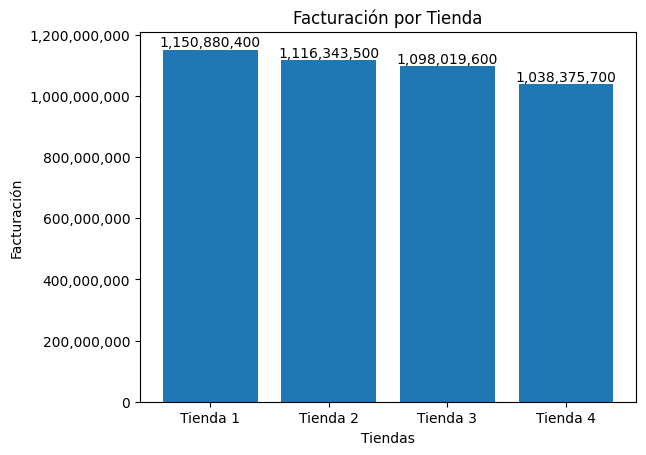

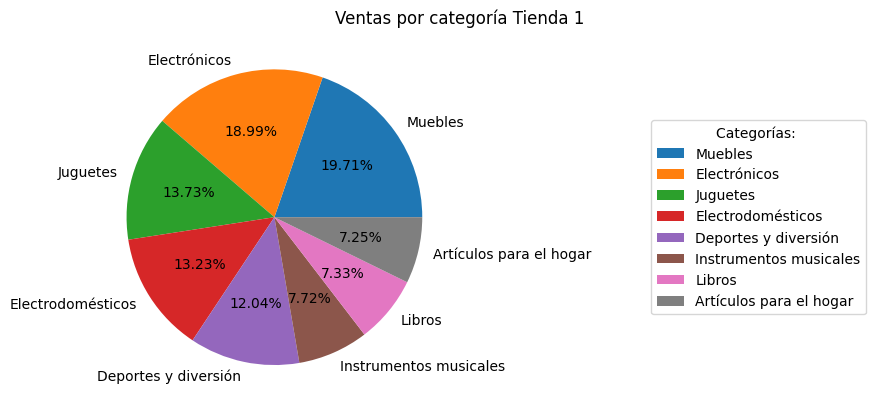

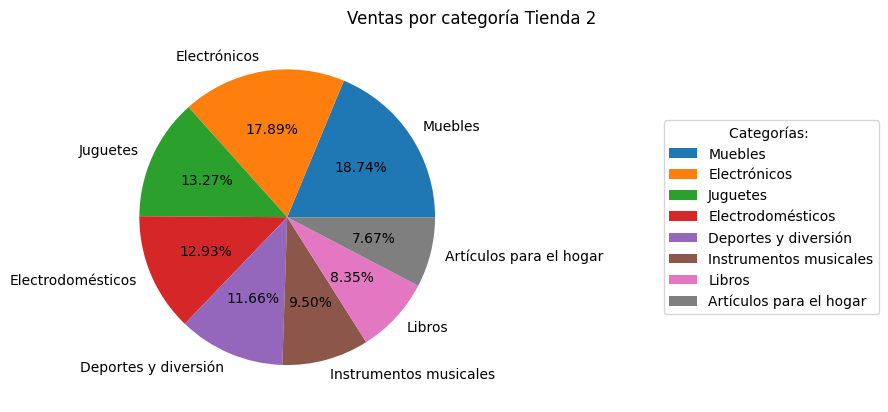

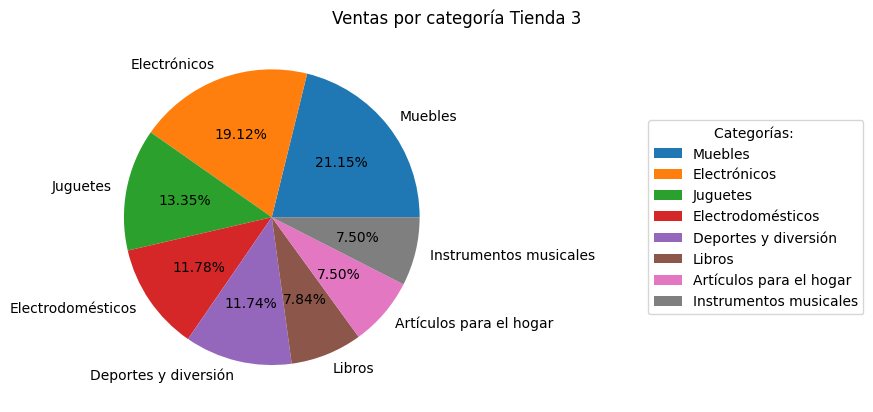

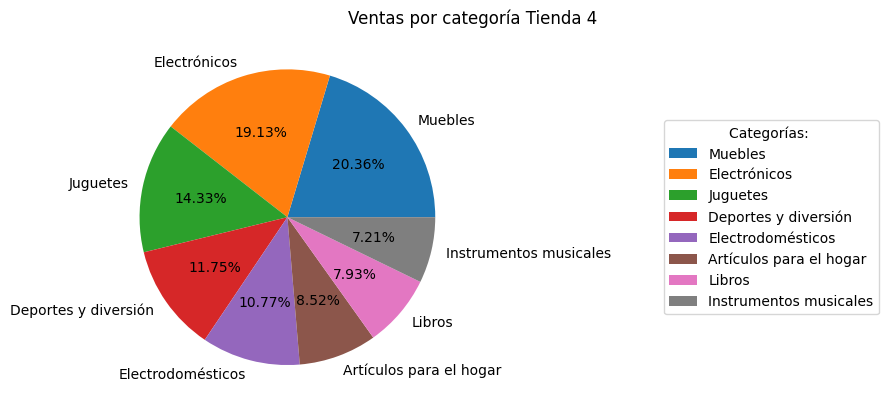

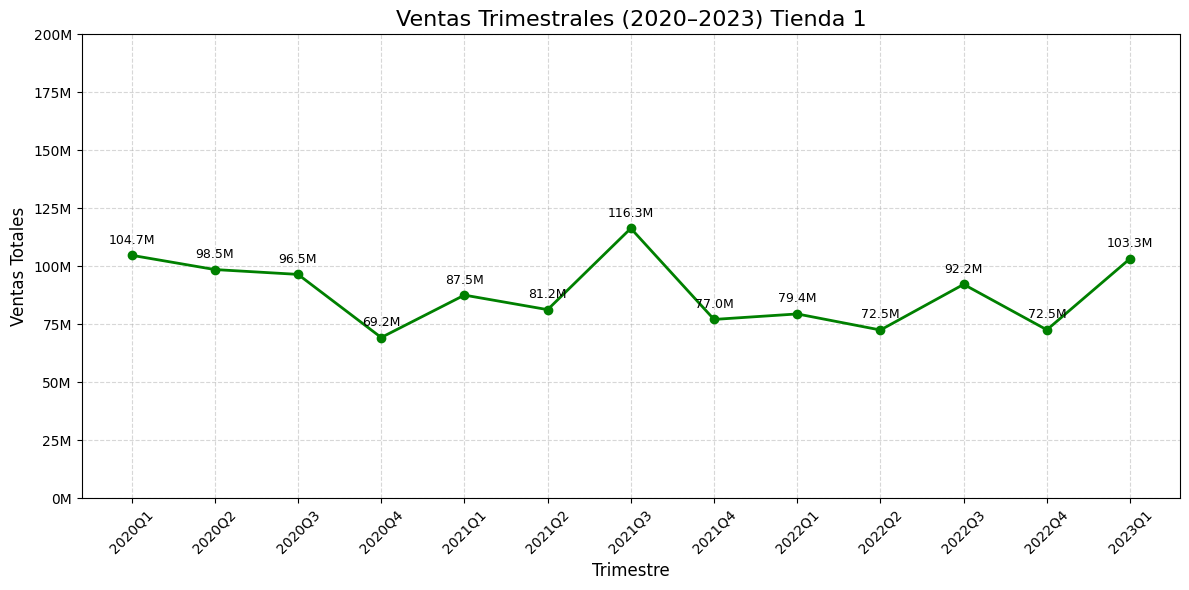

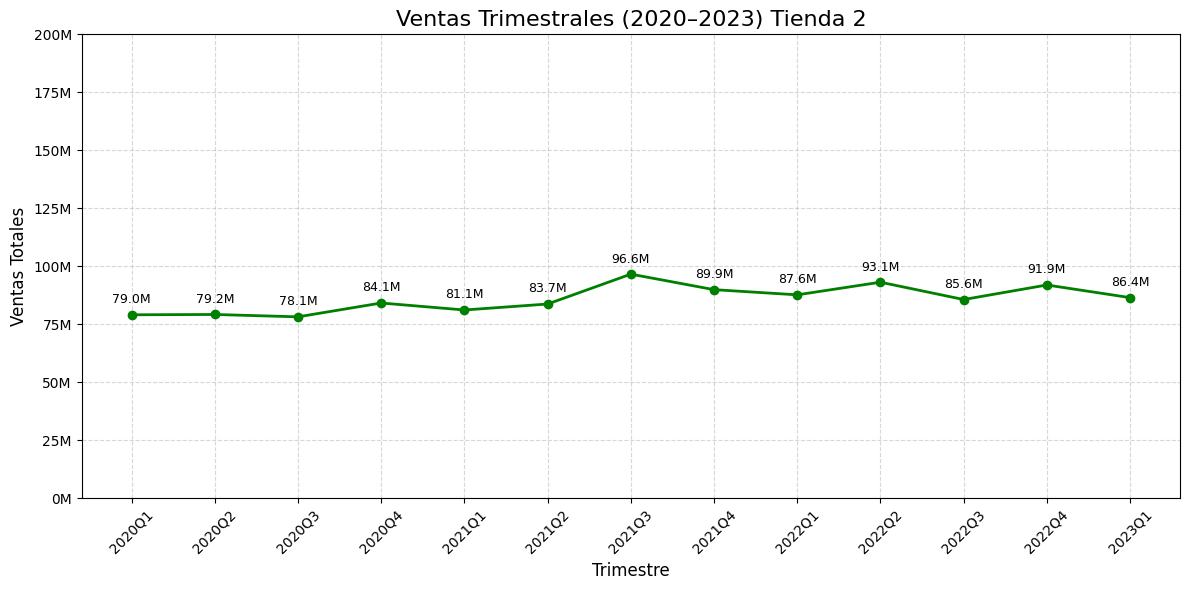

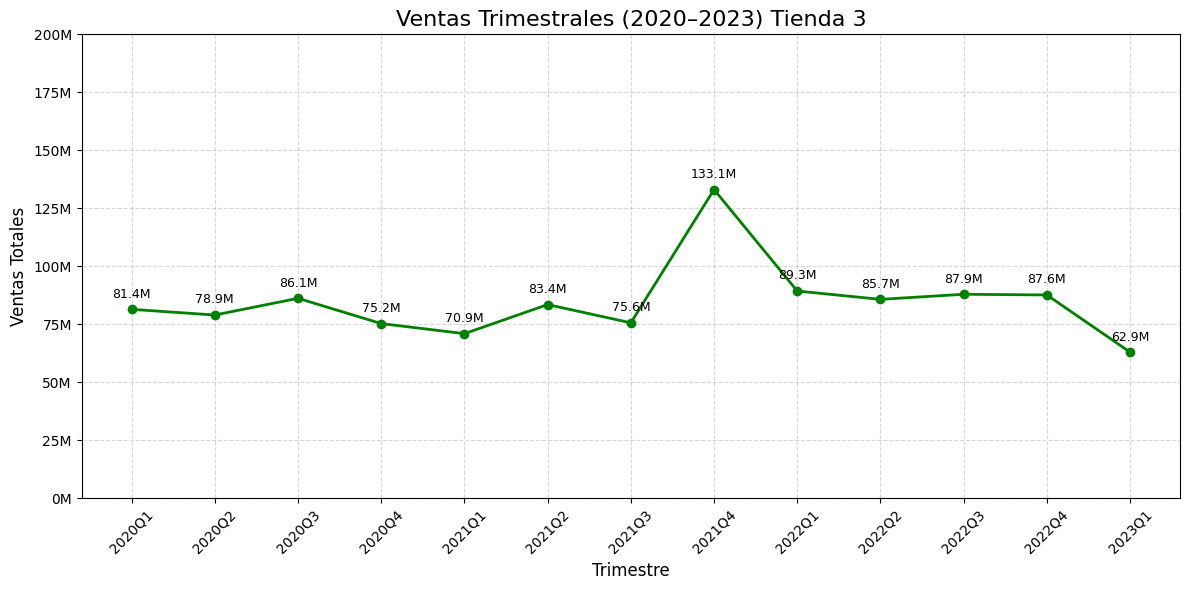

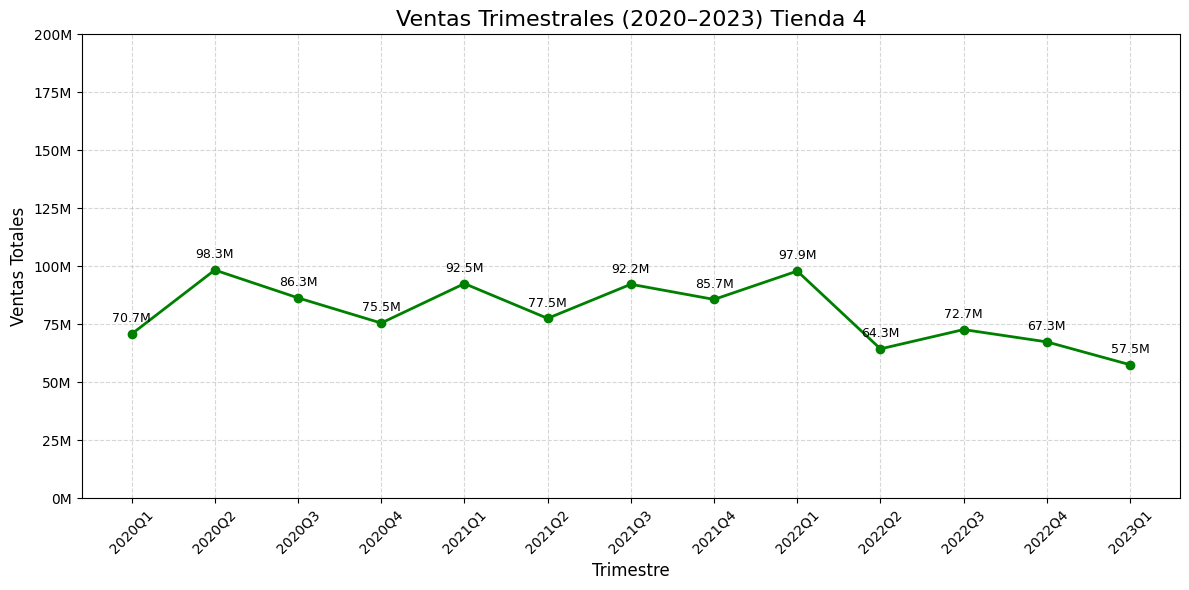

In [41]:
import matplotlib.pyplot as plt

#### Datos requeridos
# Facturaciones totales:            fact_T1, fact_T2, fact_T3, fact_T4
# Ventas por categoría:             ventas_cat_tienda1, ventas_cat_tienda2, ventas_cat_tienda3, ventas_cat_tienda4
# Facturación total por categoría:  fact_por_cat_T1, fact_por_cat_T2, fact_por_cat_T3, fact_por_cat_T4
# Calificación promedio por tienda: calificacion_media_T1, calificacion_media_T2, calificacion_media_T3, calificacion_media_T4
# Costo promedio de envío:          envío_promedio_T1, envío_promedio_T2, envío_promedio_T3, envío_promedio_T4


#### GRAFICO DE FACTURACIÓN POR TIENDA ####

Tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
facturaciones = [fact_T1, fact_T2, fact_T3, fact_T4]

plt.bar(Tiendas, facturaciones)
plt.gca().yaxis.set_major_formatter("{x:,.0f}")   # Da formato al eje y para visualizar los valores completos

# Se utiliza para añadir los valores encima de las barras.
for i, v in enumerate(facturaciones):
    plt.text(i, v + 10, f'{v:,.0f}', ha='center', va='bottom')  # Ajusta el 10 según sea necesario

# Agregando títulos
plt.title('Facturación por Tienda')
plt.xlabel('Tiendas')
plt.ylabel('Facturación')

plt.show()

#### GRAFICO DE VENTAS POR CATEGORIA ####

def graficar_ventas_cat(Ventas_por_cat,Tienda_Num):
  # Nombres y valores de las ventas por categoría
  nombres = list(Ventas_por_cat.keys())
  valores = list(Ventas_por_cat.values())

  plt.title(f'Ventas por categoría Tienda {Tienda_Num}', x=1)
  plt.pie(valores, labels = nombres, autopct='%1.2f%%')
  plt.legend(title = 'Categorías: ', loc='center left', bbox_to_anchor=(1.5, 0.5))
  plt.show()

  return

graficar_ventas_cat(ventas_cat_tienda1,1)
graficar_ventas_cat(ventas_cat_tienda2,2)
graficar_ventas_cat(ventas_cat_tienda3,3)
graficar_ventas_cat(ventas_cat_tienda4,4)


#### GRAFICO DE FACTURACIÓN TRIMESTRAL (2020 AL 2023) ####

factura_trimestres_T1 = factura_por_trimestres(tienda)
factura_trimestres_T2 = factura_por_trimestres(tienda2)
factura_trimestres_T3 = factura_por_trimestres(tienda3)
factura_trimestres_T4 = factura_por_trimestres(tienda4)

graficar_ventas(factura_trimestres_T1,1)
graficar_ventas(factura_trimestres_T2,2)
graficar_ventas(factura_trimestres_T3,3)
graficar_ventas(factura_trimestres_T4,4)


# 8. Informe Final

### **INTRODUCCIÓN**

Este documento es realizado con el objetivo de dar a conocer al Sr. Juan el estado actual de sus tiendas teniendo presente los siguientes factores:

1. Los ingresos totales de las tiendas.
2. Las categorías de productos más y menos vendidas.
3. Las calificaciones promedio de los clientes por tienda.
4. Los productos más y menos vendidos.
5. El coste de envío promedio para cada tienda.
6. Facturación trimestral periodo 2020-2023

Y concluir cuál de las tiendas en revisión debe ser vendida.

<br>

### **1. INGRESOS TOTALES DE LAS TIENDAS**


+ La facturación total de la tienda 1 es: $ 1,150,880,400.00

+ La facturación total de la tienda 2 es: $ 1,116,343,500.00

+ La facturación total de la tienda 3 es: $ 1,098,019,600.00

+ La facturación total de la tienda 4 es: $ 1,038,375,700.00

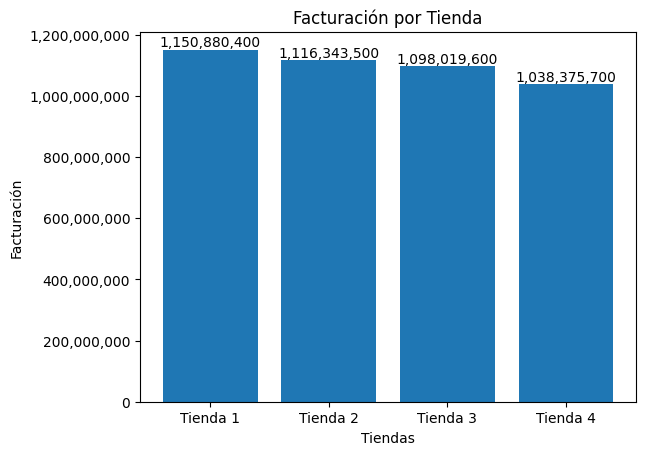

<br>

### **2.1 CATEGORÍAS DE PRODUCTOS MÁS VENDIDOS**

- La categoría de productos más vendida de la tienda 1 es: **Muebles** (465 ventas) con una facturación de **$187.633.700**.

- Las categorías de productos más vendidas de la tienda 2 son: **Muebles** (422 ventas) con una facturación de **$176.426.300**.

- La categoría de productos más vendida de la tienda 3 es: **Muebles** (499 ventas) con una facturación de **$201.072.100**.

- La categoría de productos más vendida de la tienda 4 es: **Muebles** (480 ventas) con una facturación de **$192.528.900**.

<br>

### **2.2 CATEGORÍAS DE PRODUCTOS MENOS VENDIDOS**

- La categoría de productos menos vendida de la tienda 1 es: **Artículos para el hogar** (171 ventas) con una facturación de **$12.698.400**.

- Las categorías de productos menos vendidas de la tienda 2 son: **Artículos para el hogar** (181 ventas) con una facturación de **$14.746.900**.

- La categoría de productos menos vendida de la tienda 3 es: **Instrumentos musicales** (177 ventas) con una facturación de **$77.380.900**.

- La categoría de productos menos vendida de la tienda 4 es: **Instrumentos musicales** (170 ventas) con una facturación de **$75.102.400**.

<br>

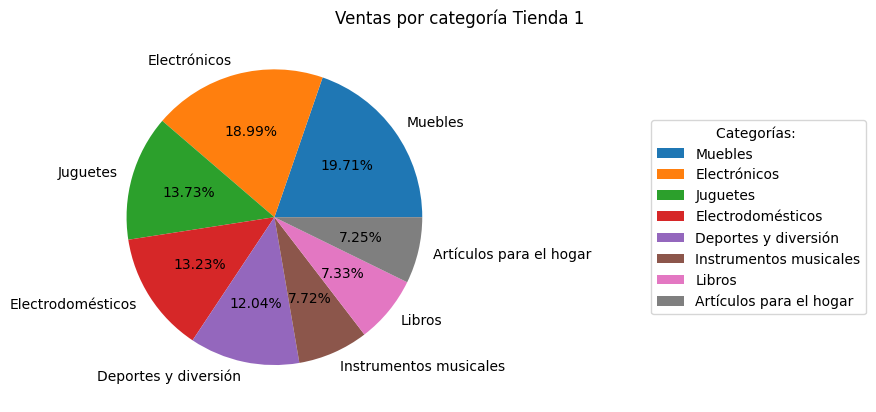

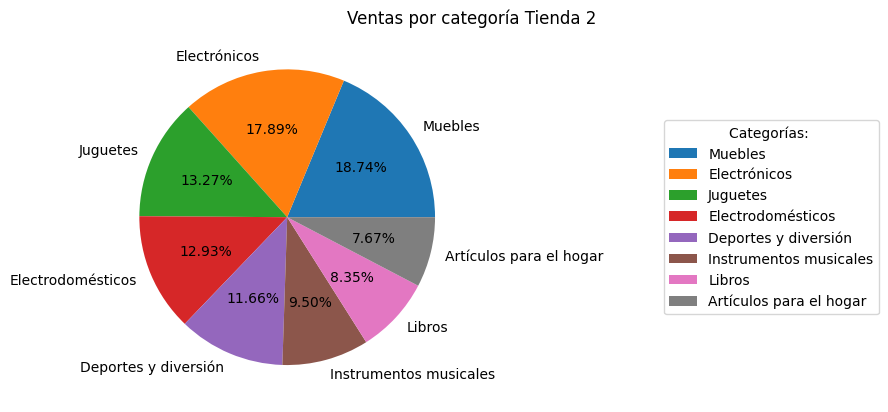

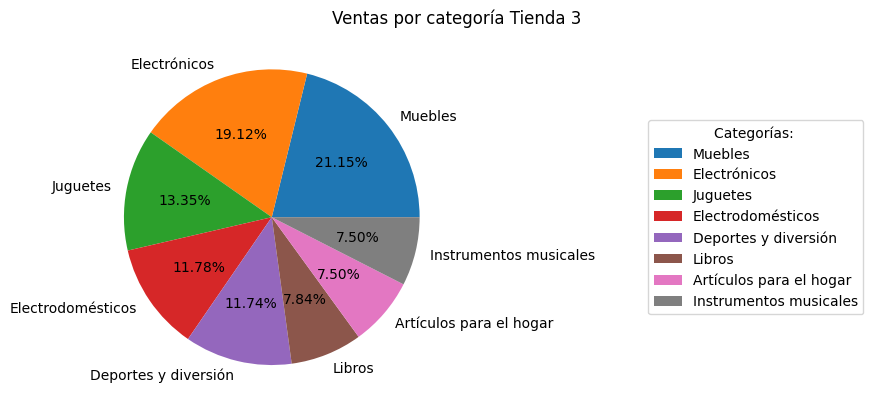

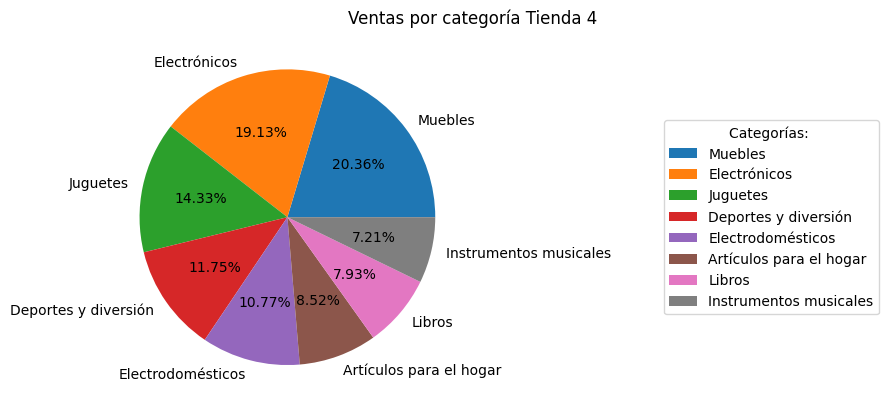

### **3. CALIFICACIONES PROMEDIO DE LOS CLIENTES**

- La calificación promedio de los clientes para la Tienda 1 es: 3.98

- La calificación promedio de los clientes para la Tienda 2 es: 4.04

- La calificación promedio de los clientes para la Tienda 2 es: 4.05

- La calificación promedio de los clientes para la Tienda 2 es: 4.0

<br>

### **4. LOS PRODUCTOS MÁS Y MENOS VENDIDOS**

### Tienda 1
- El producto más vendido de la Tienda 1 es: **TV LED UHD 4K** (60 unidades).

- El producto menos vendido de la Tienda 1 es: **Auriculares con micrófono** (33 unidades).

### Tienda 2
- El producto más vendido de la Tienda 2 es: **Iniciando en programación** (65 unidades).

- El producto menos vendido de la Tienda 2 es: **Juego de mesa** (32 unidades).

### Tienda 3
- El producto más vendido de la Tienda 3 es: **Kit de bancas** (57 unidades).

- El producto menos vendido de la Tienda 3 es: **Bloques de construcción** (35 unidades).

### Tienda 4
- El producto más vendido de la Tienda 4 es: **Cama box** (62 unidades).

- El producto menos vendido de la Tienda 4 es: **Guitarra eléctrica** (33 unidades).

<br>

### **5. COSTO PROMEDIO DE ENVÍO**

- El costo promedio de envío para la Tienda 1 es: $26,019

- El costo promedio de envío para la Tienda 2 es: $25,216

- El costo promedio de envío para la Tienda 3 es: $24,806

- El costo promedio de envío para la Tienda 4 es: $23,459

<br>

### **6. FACTURACIÓN TRIMESTRAL PERIODO 2020-2023**

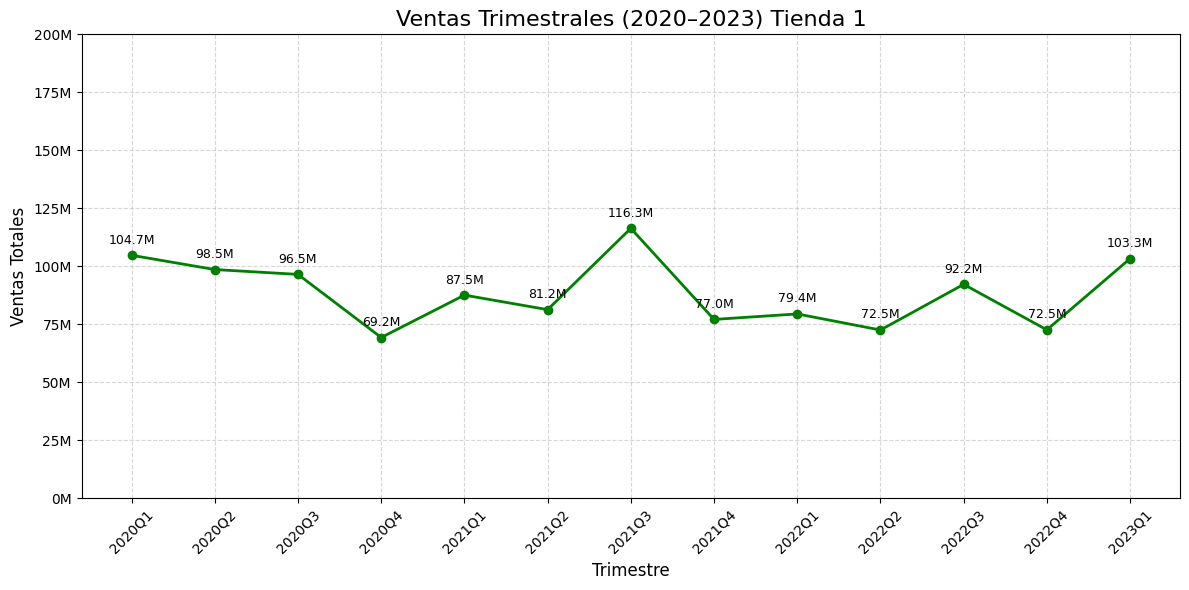

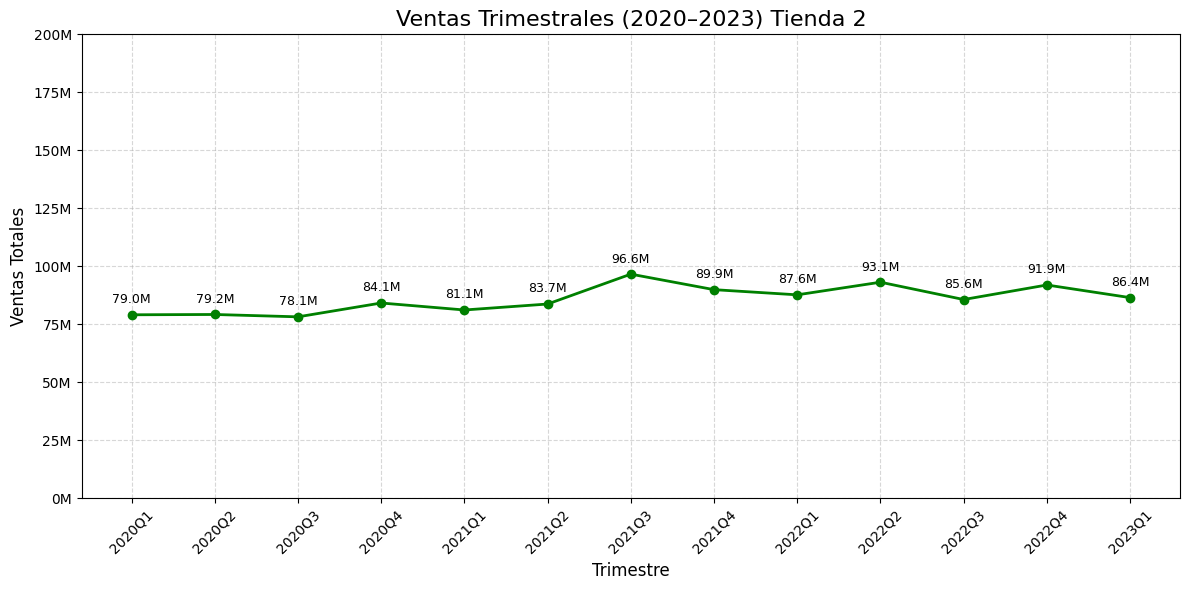

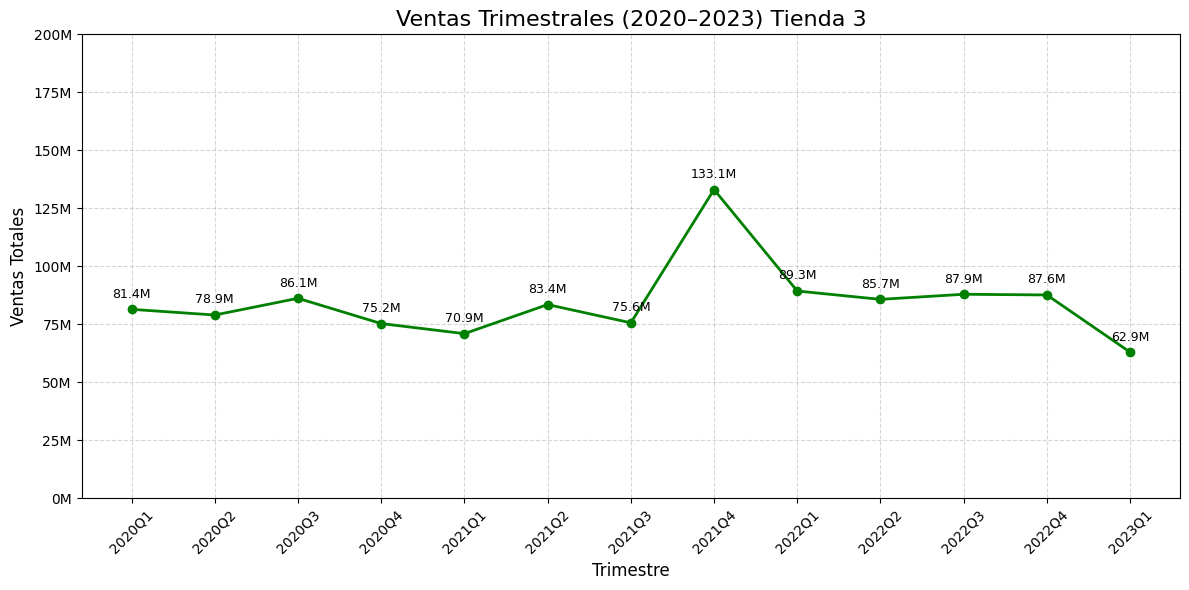

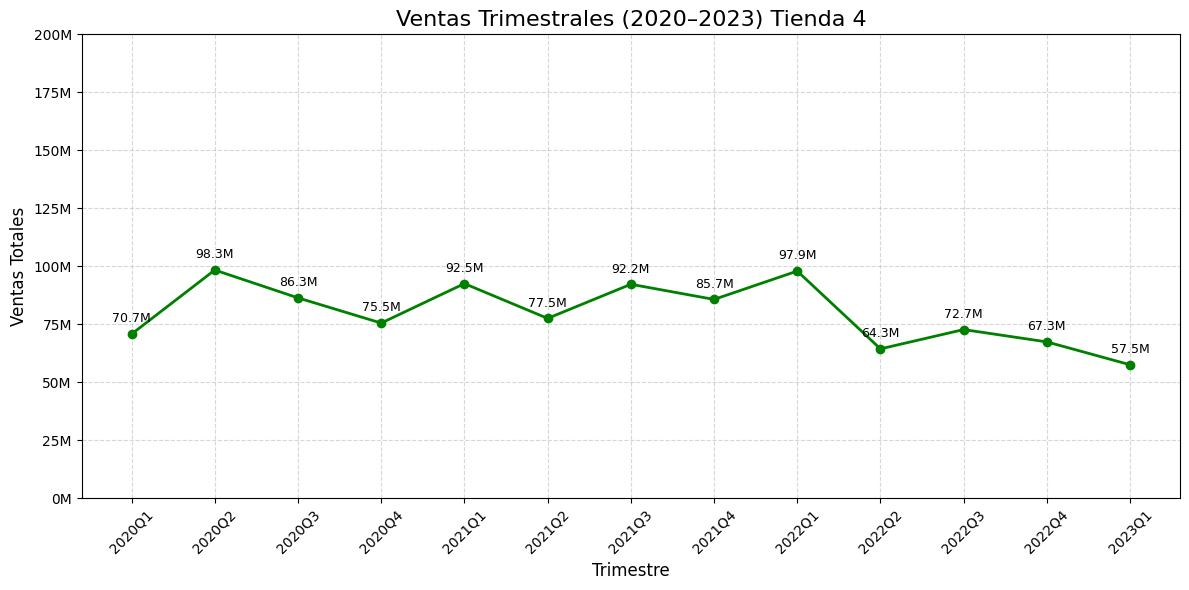

<br>

### **ANÁLISIS** ###

📌 Tienda 4 es la de menor facturación total.

📌 Tienda 1 es la líder en facturación, especialmente en electrónicos y electrodomésticos.

<br>

### Respecto a Tienda 4

🔹 Alta dependencia en electrónicos y electrodomésticos (~67%).

🔹 Poca diversidad de ingresos, bajo rendimiento en juguetes, libros y hogar.

Comparativamente, la Tienda 3 tiene mejor balance (muebles 18.3%, electrónicos 37.4%, electrodomésticos 30%).

<br>

## Costo de envío promedio

Aunque Tienda 4 tiene el costo de envío más bajo ($23,459), la diferencia con el resto es marginal comparado con la caída en facturación.

<br>

## Productos más/menos vendidos

Tienda 4 tiene entre sus productos menos vendidos:

- Celular ABXY.

- Guitarra acústica.

- Armario.

- Lavadora de ropa.

Esto sugiere bajo movimiento en categorías que deberían generar ventas altas, como tecnología, instrumentos y muebles. Su top de productos más vendidos tiene una inclinación hacia productos de menor nicho, como panderetas y cubertería.

<br>

## Comportamiento de ventas por trimestre (2020–2023)

<br>
🟢 Tienda 1.

Presenta picos de venta importantes (2021Q3, 2023Q1). Muestra una recuperación clara en 2023.
Comportamiento estable y creciente a largo plazo.

<br>
🔵 Tienda 2.

Es la más estable y menos volátil, con variaciones moderadas. Buen rendimiento durante todo el período. Indica un modelo de negocio sólido y maduro.

<br>
🟡 Tienda 3.

Tuvo un pico inusual en 2021Q4. Presenta una tendencia descendente en 2023, lo que requiere atención.

<br>
🔴 Tienda 4.

Aunque tuvo un buen inicio en 2021 y 2022Q1, su tendencia es claramente descendente. El 2023Q1 muestra su punto más bajo, lo cual refuerza la conclusión de que es la tienda menos rentable a largo plazo.

<br>

## **Conclusión final con base en análisis profundo y datos trimestrales**

Recomendación: Vender la Tienda 4.

- Tiene la facturación acumulada más baja.

- Su tendencia trimestral es descendente, sin signos claros de recuperación.

- Las otras tiendas muestran más estabilidad o crecimiento, lo que las hace más viables estratégicamente.